# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [2]:
df = pd.read_csv("Salary Data.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# **Dataset Overview**

In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (375, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


**Check Missing Values**

In [4]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


# **Exploratory Data Analysis (EDA)**

**Salary Distribution**

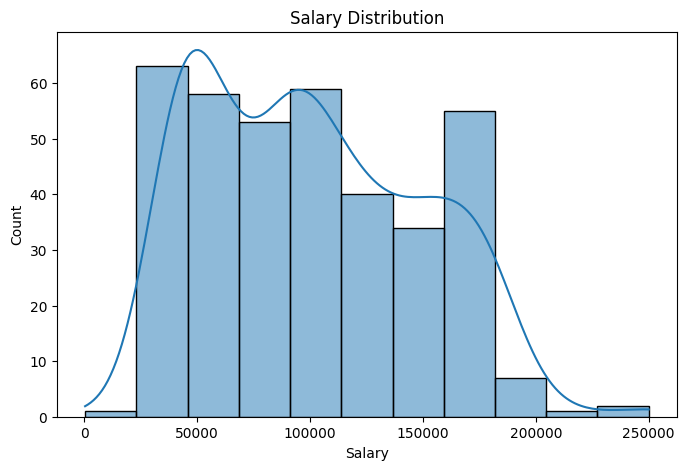

In [7]:
import os

plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)

plt.title("Salary Distribution")

os.makedirs('image', exist_ok=True)
plt.savefig("image/salary_distribution")
plt.show()

**Gender Distribution**

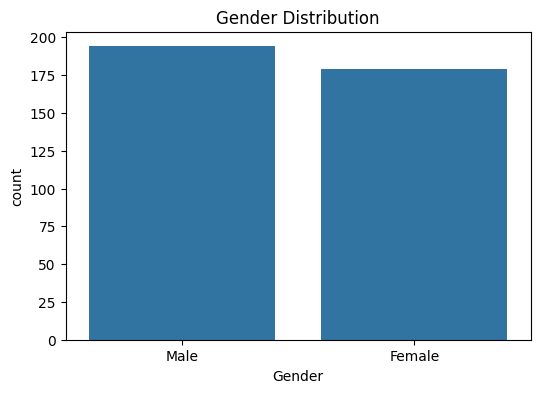

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.savefig("image/Gender Distribution")
plt.show()

**Education Level Distribution**

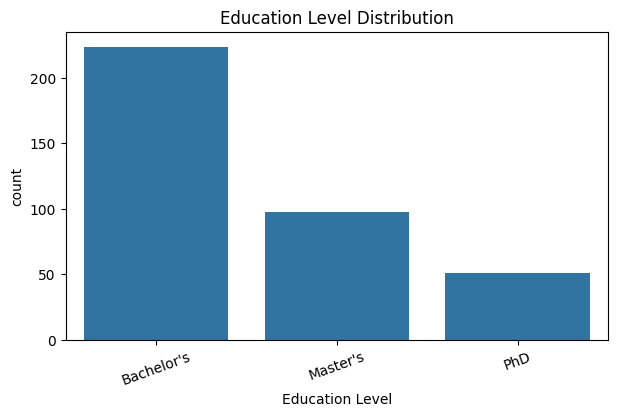

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(x="Education Level", data=df)

plt.title("Education Level Distribution")
plt.xticks(rotation=20)
plt.savefig("image/Education Level Distribution")
plt.show()

**Salary vs Experience**

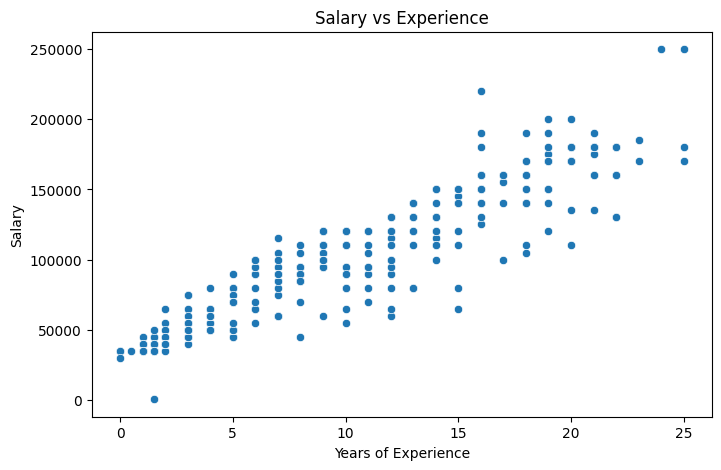

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Years of Experience",
    y="Salary",
    data=df
)
plt.savefig("image/Salary vs Experience")
plt.title("Salary vs Experience")
plt.show()

**Salary by Education**

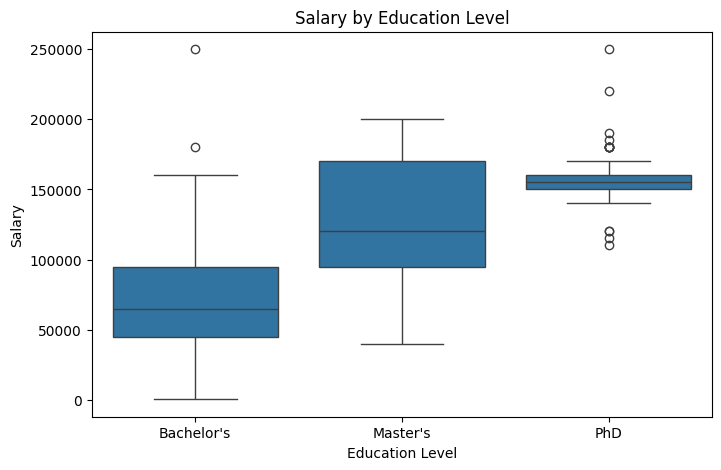

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Education Level",
    y="Salary",
    data=df
)
plt.savefig("image/Salary by Education")
plt.title("Salary by Education Level")
plt.show()

**Age vs Salary**

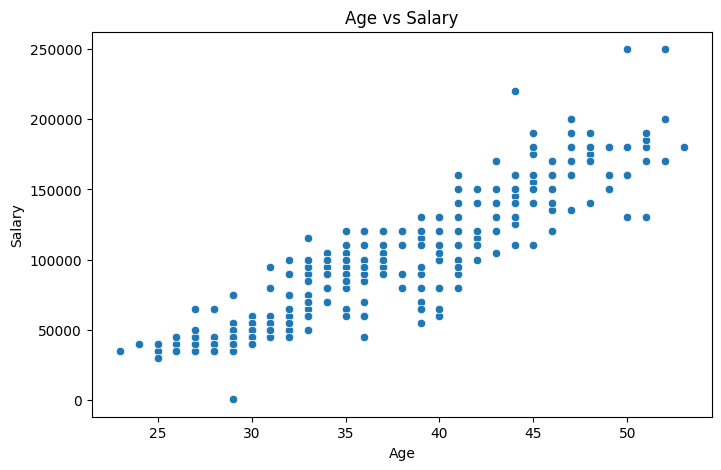

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Salary",
    data=df
)
plt.savefig("image/Age vs Salary")
plt.title("Age vs Salary")
plt.show()

**Top 10 Job Titles**

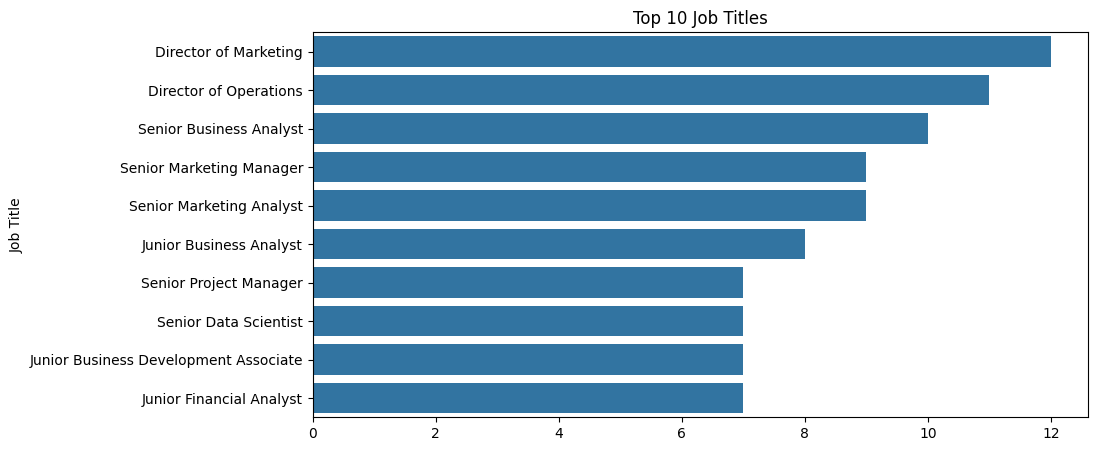

In [13]:
top_jobs = df["Job Title"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)
plt.savefig("image/Top 10 Job Titles")
plt.title("Top 10 Job Titles")
plt.show()

**Correlation Heatmap**

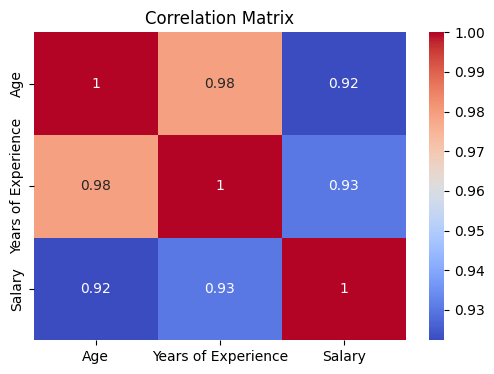

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.savefig("image/Correlation Matrix")
plt.title("Correlation Matrix")
plt.show()

# **Data Preprocessing**

**Features and Target**

In [15]:
X = df.drop("Salary", axis=1)

y = df["Salary"]

**Numerical and Categorical Columns**

In [16]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

**Preprocessing Pipeline**

In [17]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# **Train Test Split**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Model 1: Linear Regression**

In [20]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Create copies to avoid modifying the original X_train, y_train if they are used elsewhere
X_train_cleaned = X_train.copy()
y_train_cleaned = y_train.copy()

# Identify and remove NaNs from y_train and corresponding X_train rows
nan_indices = y_train_cleaned[y_train_cleaned.isna()].index
X_train_cleaned = X_train_cleaned.drop(nan_indices)
y_train_cleaned = y_train_cleaned.drop(nan_indices)

lr_pipeline.fit(X_train_cleaned, y_train_cleaned)

lr_pred = lr_pipeline.predict(X_test)

**Evaluation**

In [23]:
# Create a boolean mask for non-NaN values in y_test
non_nan_mask = y_test.notna()

# Filter y_test using the boolean mask (retains original index)
y_test_cleaned = y_test[non_nan_mask]

# Filter lr_pred using the boolean mask's values (for numpy array lr_pred)
lr_pred_cleaned = lr_pred[non_nan_mask.values]

print("R2 Score:", r2_score(y_test_cleaned, lr_pred_cleaned))
print("MAE:", mean_absolute_error(y_test_cleaned, lr_pred_cleaned))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cleaned, lr_pred_cleaned)))

R2 Score: 0.8519929304935238
MAE: 12317.897093062329
RMSE: 19062.799641878162


# **Model 2: Random Forest**

In [25]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train_cleaned, y_train_cleaned)

rf_pred = rf_pipeline.predict(X_test)

**Evaluation**

In [27]:
# Create a boolean mask for non-NaN values in y_test
non_nan_mask = y_test.notna()

# Filter y_test using the boolean mask (retains original index)
y_test_cleaned = y_test[non_nan_mask]

# Filter rf_pred using the boolean mask's values (for numpy array rf_pred)
rf_pred_cleaned = rf_pred[non_nan_mask.values]

print("R2 Score:", r2_score(y_test_cleaned, rf_pred_cleaned))
print("MAE:", mean_absolute_error(y_test_cleaned, rf_pred_cleaned))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cleaned, rf_pred_cleaned)))

R2 Score: 0.8646693276396823
MAE: 10915.878378378378
RMSE: 18228.191106456874


# **Model Comparison**

In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test_cleaned, lr_pred_cleaned),
        r2_score(y_test_cleaned, rf_pred_cleaned)
    ],
    "MAE": [
        mean_absolute_error(y_test_cleaned, lr_pred_cleaned),
        mean_absolute_error(y_test_cleaned, rf_pred_cleaned)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_cleaned, lr_pred_cleaned)),
        np.sqrt(mean_squared_error(y_test_cleaned, rf_pred_cleaned))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.851993,12317.897093,19062.799642
1,Random Forest,0.864669,10915.878378,18228.191106


# **Feature Importance**

In [30]:
rf_model = rf_pipeline.named_steps["model"]

feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

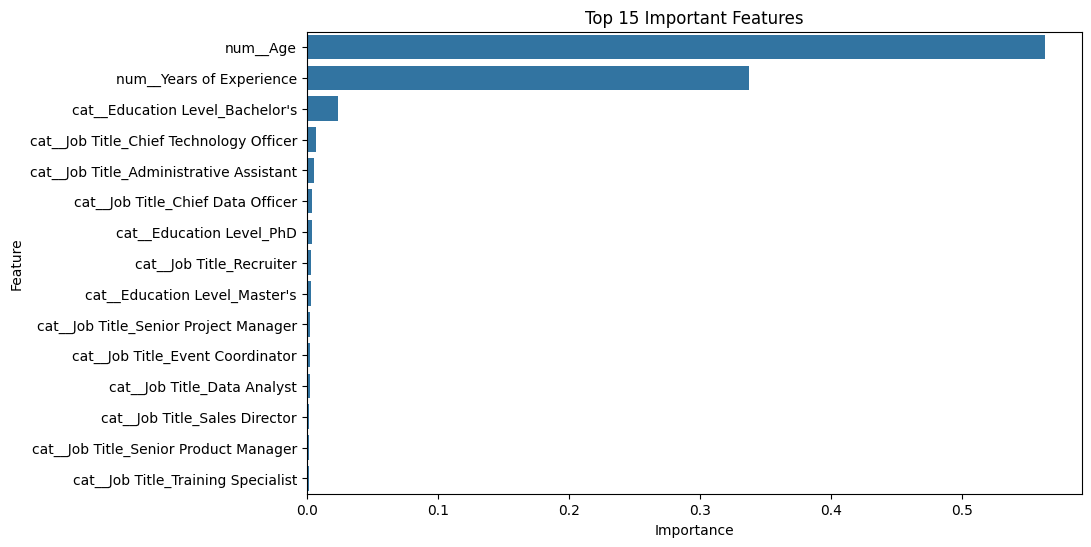

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)
plt.savefig("image/Top 15 Important Features")
plt.title("Top 15 Important Features")
plt.show()

# **Prediction Example**

In [32]:
sample = pd.DataFrame({
    "Age":[30],
    "Gender":["Male"],
    "Education Level":["Bachelor's"],
    "Job Title":["Data Analyst"],
    "Years of Experience":[5]
})

pred_salary = rf_pipeline.predict(sample)

print("Predicted Salary:", pred_salary[0])

Predicted Salary: 49725.0


# **Conclusion**

Key Findings

1. Years of Experience has the strongest impact on salary.
2. Education Level contributes significantly to salary prediction.
3. Job Title introduces valuable categorical information.
4. Random Forest outperformed Linear Regression.
5. Proper preprocessing improved model reliability.

Future Improvements

• Hyperparameter tuning
• XGBoost implementation
• Model deployment using Streamlit
• Cross-validation